# ***Credit Card Fraud Detection System***

### Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score,classification_report, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

### Importing the dataset

In [2]:
data = pd.read_csv("creditcard_2023.csv")
data.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0.0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0.0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0.0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0.0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0.0


### Data Preprocessing

In [3]:
data.shape

(234873, 31)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234873 entries, 0 to 234872
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      234873 non-null  int64  
 1   V1      234873 non-null  float64
 2   V2      234873 non-null  float64
 3   V3      234873 non-null  float64
 4   V4      234873 non-null  float64
 5   V5      234873 non-null  float64
 6   V6      234873 non-null  float64
 7   V7      234873 non-null  float64
 8   V8      234873 non-null  float64
 9   V9      234873 non-null  float64
 10  V10     234873 non-null  float64
 11  V11     234873 non-null  float64
 12  V12     234873 non-null  float64
 13  V13     234873 non-null  float64
 14  V14     234873 non-null  float64
 15  V15     234873 non-null  float64
 16  V16     234873 non-null  float64
 17  V17     234873 non-null  float64
 18  V18     234873 non-null  float64
 19  V19     234873 non-null  float64
 20  V20     234873 non-null  float64
 21  V21     23

In [5]:
data.isna().sum()

,0
id,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [6]:
data = data.fillna(0)

In [7]:
X = data.drop(['id','Class'],axis = 1,errors = 'ignore')
y = data['Class']

In [8]:
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,...,0.091202,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10
1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,...,-0.233984,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37
2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,...,0.361652,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54
3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,...,-0.378223,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44
4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,...,0.247237,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234868,1.666037,-0.522949,0.008576,-0.399655,0.240454,0.117430,0.366390,-0.167647,1.118263,0.427402,...,-0.260232,-0.122258,-0.161733,0.177836,1.265202,-0.511415,0.895971,-0.293628,-0.138744,4252.99
234869,1.638985,-0.475704,-0.116850,-0.590679,0.813688,1.084792,0.370714,-0.061415,0.673662,0.461255,...,-0.419038,-0.202231,-0.522194,0.376514,-1.376234,-0.865922,0.602391,-0.256102,-0.232111,4440.89
234870,1.480013,-0.803033,0.944822,0.018885,-0.177446,1.133835,-0.003004,-0.008670,2.309436,0.594519,...,-0.426495,-0.038176,0.848626,0.034118,-0.666525,-0.362584,-1.152963,-0.095388,-0.167050,16542.57
234871,1.768539,-0.586098,-0.186649,-1.131196,1.386488,2.141943,0.229389,0.049023,0.739913,0.641906,...,-0.283153,-0.292149,-1.280868,0.596306,1.400201,-1.156597,0.108484,-0.292896,-0.231460,3369.13


In [9]:
y

,Class
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
234868,0.0
234869,0.0
234870,0.0
234871,0.0


In [10]:
print(X.columns.to_list())

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [12]:
X_train

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
31380,0.812771,-0.881721,0.853549,-1.155742,0.069628,1.434356,0.075950,-0.000500,0.074668,0.840312,...,0.045856,0.060635,0.975783,-0.029487,-2.092655,-0.157906,-0.261221,-0.135651,-0.054635,2668.20
143454,-0.100861,-0.261555,2.558799,-0.647317,0.161666,0.830605,0.467326,-0.098667,0.704576,0.555450,...,-0.010580,-0.109732,0.280506,-0.211044,0.125568,-0.424265,0.634419,-0.179281,-0.242714,11984.46
42522,0.896357,-0.455765,0.605233,-0.126243,0.209034,0.514811,0.436036,-0.136748,0.736793,0.558238,...,-0.264115,-0.179377,-0.543191,-0.079037,-0.796713,0.696985,-1.077516,-0.206895,-0.037054,8865.76
91146,-0.025316,-0.589179,1.492577,-1.130899,0.095548,0.180733,0.441306,-0.118451,-0.050869,0.688692,...,-0.607602,-0.276185,-0.820848,0.310102,0.556263,-1.417562,0.040130,-0.099754,0.332827,4773.54
42939,-0.166118,-0.490864,0.607346,-1.478608,1.116044,0.217241,0.814238,-0.154742,0.081549,0.331207,...,0.148328,-0.193079,-1.024684,0.111062,-2.197193,-0.299050,1.134640,-0.319774,0.162334,17313.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,0.969987,-0.410588,0.740170,-0.424143,0.144270,0.352199,0.378242,-0.125298,0.427432,0.632583,...,-0.325582,-0.178628,-0.550888,0.141403,0.025273,0.065272,0.259975,-0.261589,-0.090522,21190.04
103694,-0.304037,0.010195,0.830124,-0.281536,0.157675,0.045008,0.770429,-0.189319,0.391141,0.929835,...,-0.107585,-0.069314,0.444919,-0.306047,0.923117,-0.394696,-0.950810,-0.496678,-0.065787,12602.67
131932,0.136515,-0.130872,1.506084,-0.414279,0.398608,-0.013919,0.872089,-0.239818,0.220758,0.511825,...,-0.155681,-0.082135,0.290838,-0.313113,0.854173,0.306760,-0.967220,-0.372687,-0.575555,6836.59
146867,-0.600171,0.251218,-0.246803,-3.244513,1.195495,1.865070,0.284574,0.398915,0.876869,0.586664,...,0.255971,-0.239136,-0.946742,0.122728,1.464994,0.444647,0.921708,0.383975,0.709445,8111.76


In [13]:
y_train

,Class
31380,0.0
143454,0.0
42522,0.0
91146,0.0
42939,0.0
...,...
119879,0.0
103694,0.0
131932,0.0
146867,0.0


In [14]:
X_test

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
93364,0.922666,-0.112930,-0.061603,0.025824,0.576049,-0.663001,0.764507,-0.236771,0.272846,0.074165,...,-0.085255,-0.173575,-0.551393,-0.286150,0.138559,1.301831,-0.712958,-0.209894,0.160781,5285.49
129194,1.040995,-0.143479,-0.376342,-0.413753,2.156838,1.728636,0.509844,-0.007979,0.185785,0.094646,...,-0.035804,-0.205574,-0.771432,-0.284724,1.457846,1.628894,-0.664480,-0.195374,0.126797,3184.16
14179,0.928391,-0.486155,1.070297,-0.393517,-0.020268,0.431838,0.248257,-0.088766,0.676706,0.631448,...,-0.361058,-0.106274,-0.117278,0.128963,0.451268,-0.101733,0.492322,-0.239640,-0.069894,19545.26
95503,-0.020647,-0.347095,1.999452,-0.351792,-0.197114,0.740482,0.204553,0.060355,1.098477,0.282514,...,-0.390962,-0.103541,0.172463,0.069075,1.224490,-0.805711,0.568970,-0.284601,-0.157601,15146.00
50473,0.668068,-0.683047,0.993128,-0.199833,-0.024422,0.792366,0.255626,-0.069998,0.787729,0.607727,...,0.000810,0.004330,0.320221,-0.202908,-0.550597,0.228633,-0.829960,-0.194372,0.025407,17275.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217546,-0.446207,-1.544451,0.400801,-0.492719,2.901228,-1.537566,0.115518,-0.173621,0.699726,0.413337,...,0.638123,-0.082315,-0.625662,0.905356,1.313882,-2.081478,-0.201342,-0.318817,0.242224,4178.08
207845,-0.261619,-0.048024,1.673201,0.115655,0.753514,1.363316,0.424090,0.082926,-0.337181,0.661101,...,-0.330647,-0.021610,0.200223,-0.539632,-0.745775,1.264636,0.205141,-0.358305,-0.212268,10196.58
89065,0.111780,-1.516198,0.637007,-0.300060,-0.275137,0.668075,0.509323,-0.150563,1.280449,0.295009,...,1.139067,-0.014303,-0.635963,-0.531460,0.414454,-0.399357,1.801767,-0.405598,0.225388,9217.31
185690,1.414118,-0.941796,0.175451,-0.341571,-0.061249,0.480757,0.253736,-0.137747,0.306938,1.177591,...,-0.516812,-0.175706,-0.401849,0.039440,-0.836871,-0.537792,-1.740812,-0.212630,-0.131459,12792.45


In [15]:
y_test

,Class
93364,0.0
129194,0.0
14179,0.0
95503,0.0
50473,0.0
...,...
217546,0.0
207845,0.0
89065,0.0
185690,0.0


In [16]:
X_train.shape

(187898, 29)

In [17]:
X_test.shape

(46975, 29)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
print(pd.Series(y_train).value_counts(normalize = True))

Class
0.0    0.998095
1.0    0.001905
Name: proportion, dtype: float64


In [20]:
model = RandomForestClassifier(n_estimators = 100,random_state = 42,max_depth = 10,min_samples_split = 5)

In [21]:
cv_scores = cross_val_score(model,X_train_scaled,y_train,cv = 5, scoring = 'f1')
print('\nCross-validation F1 scores :',cv_scores)
print('\nAverage F1 score :',np.mean(cv_scores))


Cross-validation F1 scores : [0.85714286 0.81203008 0.875      0.8358209  0.87878788]

Average F1 score : 0.8517563413282188


In [22]:
model.fit(X_train_scaled,y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, random_state=42)

In [23]:
y_pred = model.predict(X_test_scaled)

In [24]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     46906
         1.0       0.93      0.75      0.83        69

    accuracy                           1.00     46975
   macro avg       0.96      0.88      0.92     46975
weighted avg       1.00      1.00      1.00     46975



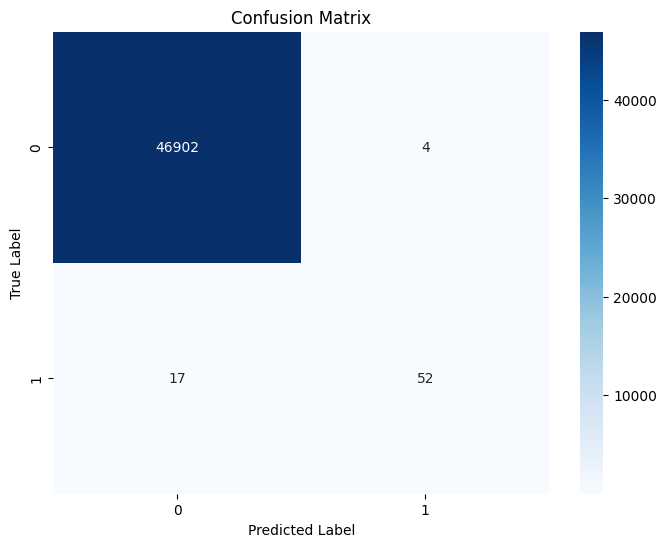

In [25]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot = True,fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [27]:
importance = model.feature_importances_
feature_imp = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : importance
}).sort_values('Importance',ascending = False)

In [29]:
feature_imp.head()

,Feature,Importance
16,V17,0.168963
11,V12,0.145508
13,V14,0.120701
9,V10,0.098095
15,V16,0.096005


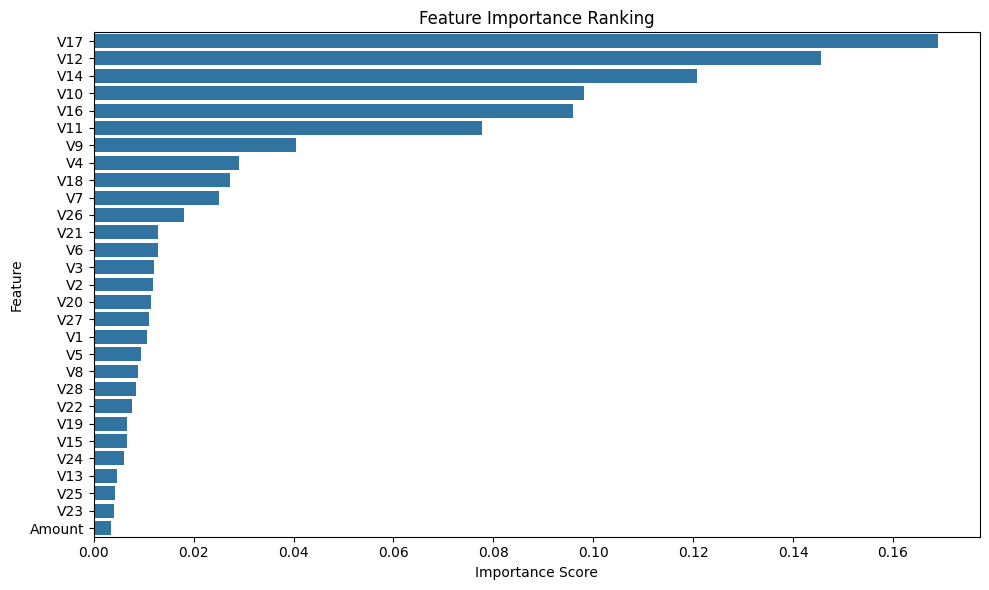

In [31]:
plt.figure(figsize = (10,6))
sns.barplot(data = feature_imp,x = 'Importance',y = 'Feature')
plt.title('Feature Importance Ranking')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

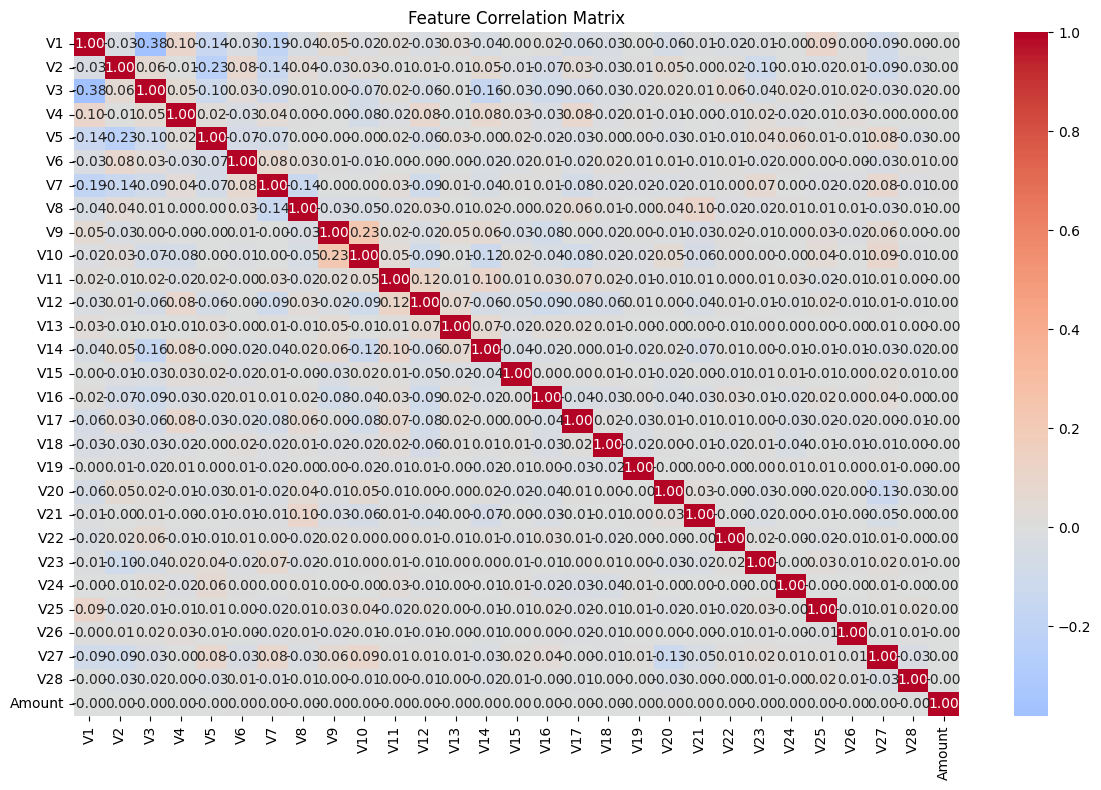

In [33]:
plt.figure(figsize = (12,8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix,cmap = 'coolwarm',center = 0,annot = True, fmt = '.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [35]:
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
fpr,tpr,_ = roc_curve(y_test,y_pred_proba)
roc_auc = auc(fpr,tpr)

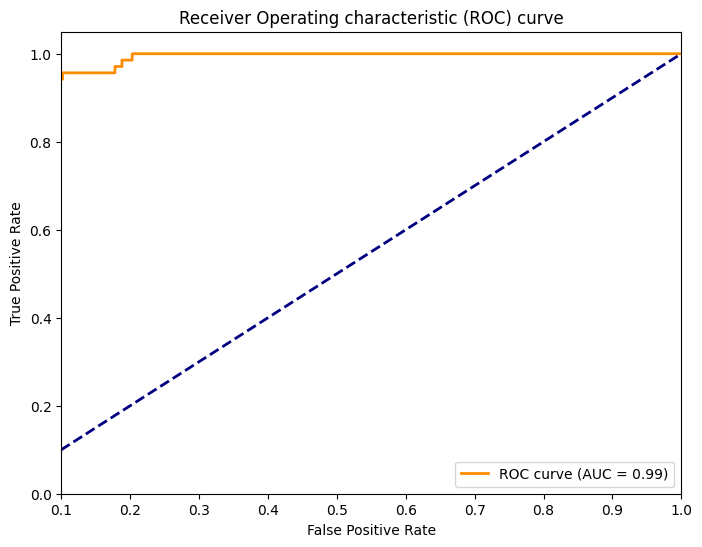

In [37]:
plt.figure(figsize = (8,6))
plt.plot(fpr,tpr,color = "darkorange",lw = 2, label = f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],color = "navy",lw = 2, linestyle = '--')
plt.xlim([0.1,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating characteristic (ROC) curve')
plt.legend(loc = 'lower right')
plt.show()